<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/08_pca_risk_reduction_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

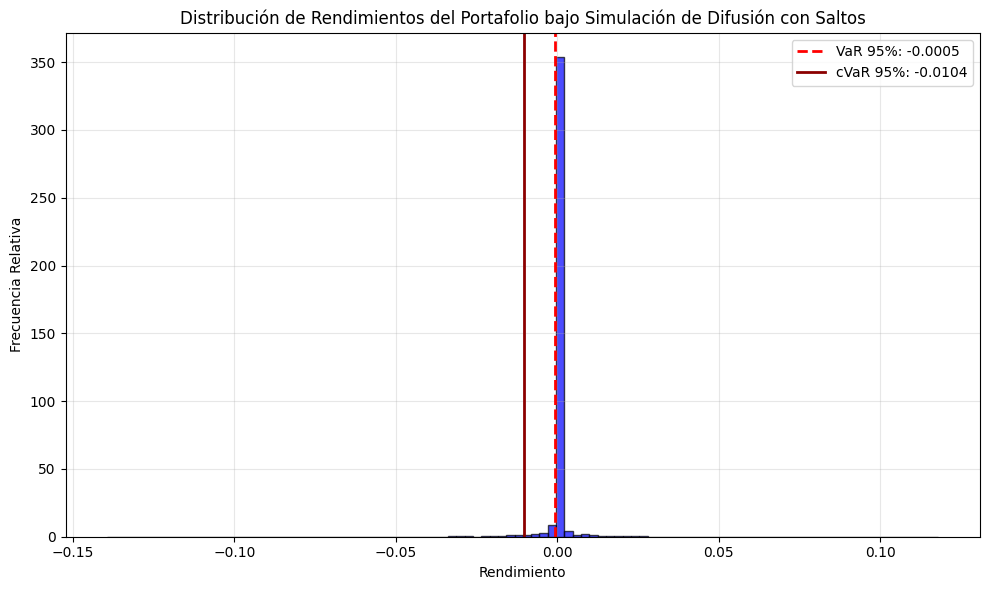

Valor Inicial Portafolio: 163.000000
VaR 95%: -0.000528
cVaR 95%: -0.010366
VaR 99%: -0.015585
cVaR 99%: -0.032388


In [ ]:
# Importación de librerías científicas necesarias
import numpy as np
import pandas as pd
from scipy.stats import genpareto
import matplotlib.pyplot as plt

def simulacion_monte_carlo_saltos():
    """
    Simulación Monte Carlo vectorizada para la estimación de VaR y cVaR
    bajo un modelo de difusión con saltos (Jump-Diffusion).
    """

    # =========================================================================
    # MÓDULO 1: Inicialización de Parámetros
    # =========================================================================
    # Valores iniciales de los activos
    SP500_0 = 2000      # [cite: 3]
    S1_0 = 20           # [cite: 9]
    S2_0 = 100          # [cite: 10]

    # Parámetros del modelo estocástico
    dt = 1/250          # [cite: 4]
    sigma_SP500 = 0.25  # [cite: 5]
    sigma_S1 = 0.10     # [cite: 6]
    sigma_S2 = 0.40     # [cite: 7]
    r = 0.035           # [cite: 8]
    n = 10000           # [cite: 11]

    # Ponderaciones del portafolio
    w1 = 0.40           # [cite: 12]
    w2 = 0.55           # [cite: 13]
    w3 = 0.05           # [cite: 14]

    # Intensidades de Poisson (lambda)
    lambda_mdo = 14     # [cite: 20]
    lambda_Sim = 14     # [cite: 34]
    lambda_Sii = 9      # [cite: 41]

    # Parámetros de la distribución Pareto Generalizada (forma, localización, escala)
    xi_pareto = 0.00001 # [cite: 24, 38, 45]
    mu_pareto = 0       # [cite: 22, 36, 43]
    sigma_pareto = 0.02 # [cite: 23, 37, 44]

    # =========================================================================
    # MÓDULO 2: Generación de Variables Aleatorias y Correlación (Cholesky)
    # =========================================================================
    # Creación de variables aleatorias normales independientes Z(nx3)
    np.random.seed(42) # Fijación de semilla para reproducibilidad científica
    Z = np.random.normal(0, 1, size=(n, 3))
    pd.DataFrame(Z, columns=['Z_SP500', 'Z_S1', 'Z_S2']).to_csv('Z.csv', index=False) # [cite: 47]

    # Matriz de correlación rho empírica
    Rho = np.array([
        [1.0, 0.9, 0.7],  # SP500 [cite: 27]
        [0.9, 1.0, 0.6],  # S1 [cite: 27]
        [0.7, 0.6, 1.0]   # S2 [cite: 27]
    ])

    # Descomposición de Cholesky e inducción de correlación lineal
    L = np.linalg.cholesky(Rho)
    Eta = Z @ L.T
    pd.DataFrame(Eta, columns=['Eta_SP500', 'Eta_S1', 'Eta_S2']).to_csv('Eta.csv', index=False) # [cite: 47]

    # =========================================================================
    # MÓDULO 3: Procesos de Saltos (Poisson y Pareto)
    # =========================================================================
    # Generación de la probabilidad de salto en el diferencial de tiempo dt
    prob_salto_mdo = lambda_mdo * dt
    prob_salto_Sim = lambda_Sim * dt
    prob_salto_Sii = lambda_Sii * dt

    # Matriz de Poisson Poi(nx3): 1 si ocurre salto, 0 en otro caso
    # Columna 0: Salto de Mercado, Columna 1: Salto Idiosincrático S1, Columna 2: Salto Idiosincrático S2
    Poi = np.zeros((n, 3))
    Poi[:, 0] = np.random.uniform(0, 1, n) < prob_salto_mdo # dN_1t para el mercado [cite: 20]
    Poi[:, 1] = np.random.uniform(0, 1, n) < prob_salto_Sii # dN_2t para S1 [cite: 41]
    Poi[:, 2] = np.random.uniform(0, 1, n) < prob_salto_Sii # dN_2t para S2 [cite: 41]
    pd.DataFrame(Poi, columns=['Poi_Mdo', 'Poi_S1_Idio', 'Poi_S2_Idio']).to_csv('Poi.csv', index=False) # [cite: 48]

    # Funciones indicadoras (signo del salto): 1 positivo, -1 negativo
    # Asignación de signo aleatorio (50% probabilidad) al ocurrir un salto
    Ind_SP500 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1) # [cite: 17, 19]
    Ind_Sim_S1 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1) # [cite: 32, 33]
    Ind_Sim_S2 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)
    Ind_Sii_S1 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1) # [cite: 39, 40]
    Ind_Sii_S2 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)

    # Generación de variables Pareto Generalizada Par(nx3)
    # La parametrización de scipy.stats.genpareto utiliza c para la forma, loc, y scale
    Par = genpareto.rvs(c=xi_pareto, loc=mu_pareto, scale=sigma_pareto, size=(n, 3))
    pd.DataFrame(Par, columns=['Par_Mdo', 'Par_S1', 'Par_S2']).to_csv('Par.csv', index=False) # [cite: 49]

    # =========================================================================
    # MÓDULO 4: Dinámica de Precios (Ecuaciones Integro-Diferenciales)
    # =========================================================================
    # Construcción de los diferenciales de precio

    # Ecuación diferencial del mercado (SP500)
    # dSP500 = r*dt + sigma_SP500*Eta_1*dt + Ind_SP500*Nu_SP500*dN_1t*SP500_0
    dSP500 = (r * dt) + (sigma_SP500 * Eta[:, 0] * dt) + (Ind_SP500 * Par[:, 0] * Poi[:, 0] * SP500_0) # [cite: 16]

    # Lógica de contagio sistémico: Si el mercado salta, los saltos sistémicos de los activos se activan [cite: 18]
    dN_1t_activos = np.copy(Poi[:, 0])

    # Ecuaciones diferenciales de los activos individuales i = 1, 2
    # dSi = r*dt + sigma_si*Eta_1+i*dt + Ind_Sim*Nu_Sim*dN_1t*Si_0 + Ind_Sii*Nu_Sii*dN_2t*Si_0
    dS1 = (r * dt) + (sigma_S1 * Eta[:, 1] * dt) + (Ind_Sim_S1 * Par[:, 0] * dN_1t_activos * S1_0) + (Ind_Sii_S1 * Par[:, 1] * Poi[:, 1] * S1_0) # [cite: 30, 31]
    dS2 = (r * dt) + (sigma_S2 * Eta[:, 2] * dt) + (Ind_Sim_S2 * Par[:, 0] * dN_1t_activos * S2_0) + (Ind_Sii_S2 * Par[:, 2] * Poi[:, 2] * S2_0) # [cite: 30, 31]

    # Exportación de cambios
    df_cambios = pd.DataFrame({'dSP500': dSP500, 'dS1': dS1, 'dS2': dS2})
    df_cambios.to_csv('Cambios.csv', index=False) # [cite: 50]

    # Ecuaciones de actualización de precios para t+1
    SP500_1 = SP500_0 + dSP500 # [cite: 28]
    S1_1 = S1_0 + dS1 # [cite: 46]
    S2_1 = S2_0 + dS2 # [cite: 46]

    df_precios = pd.DataFrame({'SP500_1': SP500_1, 'S1_1': S1_1, 'S2_1': S2_1})
    df_precios.to_csv('Precios_Finales.csv', index=False) # [cite: 51]

    # =========================================================================
    # MÓDULO 5: Evaluación de Portafolio y Métricas de Riesgo (VaR/CVaR)
    # =========================================================================
    # Valor original del portafolio Pi_0
    Pi_0 = (w1 * S1_0) + (w2 * S2_0) + (w3 * SP500_0) # [cite: 52]

    # Valor final del portafolio Pi_1
    Pi_1 = (w1 * S1_1) + (w2 * S2_1) + (w3 * SP500_1) # [cite: 53]
    pd.DataFrame({'Pi_1': Pi_1}).to_csv('Portafolio_Final.csv', index=False) # [cite: 53]

    # Rendimiento del portafolio en cada escenario
    r_Pi = (Pi_1 / Pi_0) - 1 # [cite: 54]
    pd.DataFrame({'Rendimiento_Portafolio': r_Pi}).to_csv('Rendimientos.csv', index=False) # [cite: 54]

    # Cálculo del VaR y cVaR empíricos al 95% y 99% de nivel de confianza
    alpha_95 = 0.05
    alpha_99 = 0.01

    VaR_95 = np.percentile(r_Pi, alpha_95 * 100) # [cite: 55]
    VaR_99 = np.percentile(r_Pi, alpha_99 * 100) # [cite: 55]

    cVaR_95 = r_Pi[r_Pi <= VaR_95].mean() # [cite: 55]
    cVaR_99 = r_Pi[r_Pi <= VaR_99].mean() # [cite: 55]

    # Generación del Histograma de rendimientos
    plt.figure(figsize=(10, 6))
    plt.hist(r_Pi, bins=100, color='blue', alpha=0.7, edgecolor='black', density=True) # [cite: 56]
    plt.axvline(VaR_95, color='red', linestyle='dashed', linewidth=2, label=f'VaR 95%: {VaR_95:.4f}')
    plt.axvline(cVaR_95, color='darkred', linestyle='solid', linewidth=2, label=f'cVaR 95%: {cVaR_95:.4f}')
    plt.title('Distribución de Rendimientos del Portafolio bajo Simulación de Difusión con Saltos')
    plt.xlabel('Rendimiento')
    plt.ylabel('Frecuencia Relativa')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('Histograma_Rendimientos.png')
    plt.show()

    # Consolidación de resultados
    resultados = {
        'Valor Inicial Portafolio': Pi_0,
        'VaR 95%': VaR_95,
        'cVaR 95%': cVaR_95,
        'VaR 99%': VaR_99,
        'cVaR 99%': cVaR_99
    }

    return resultados

# Ejecución del pipeline
if __name__ == "__main__":
    metricas_riesgo = simulacion_monte_carlo_saltos()
    for metrica, valor in metricas_riesgo.items():
        print(f"{metrica}: {valor:.6f}")

In [ ]:
# =============================================================================
# NUEVA CELDA: SIMULACIÓN MONTE CARLO VIA COMPONENTES PRINCIPALES (PCA)
# =============================================================================

def simular_portafolio_pca(alpha_var: float = 0.90):
    """
    Efectúa la descomposición espectral de la matriz de correlación, aislando
    los componentes principales necesarios para cubrir el umbral alpha_var
    y recalcula la dinámica del portafolio Jump-Diffusion.
    """
    print("=========================================================================")
    print(f"INICIANDO PIPELINE DE REDUCCIÓN ESPECTRAL (PCA) | Alpha_var = {alpha_var}")
    print("=========================================================================\n")

    # 1. Recuperación de la matriz estructural Rho original
    Rho = np.array([
        [1.0, 0.9, 0.7],  # SP500
        [0.9, 1.0, 0.6],  # S1
        [0.7, 0.6, 1.0]   # S2
    ])

    # 2. Descomposición espectral (Valores propios y vectores ortonormales)
    # np.linalg.eigh es óptimo y numéricamente estable para matrices simétricas
    valores_propios, vectores_propios = np.linalg.eigh(Rho)

    # Ordenar de forma descendente (mayor a menor varianza explicada)
    indices_ordenados = np.argsort(valores_propios)[::-1]
    valores_propios = valores_propios[indices_ordenados]
    vectores_propios = vectores_propios[:, indices_ordenados]

    # Exportación e impresión de Autovalores
    df_val_prop = pd.DataFrame({'Componente': [f'PC_{i+1}' for i in range(len(valores_propios))],
                                'Valor_Propio': valores_propios})
    df_val_prop.to_csv('valores_propios.csv', index=False)

    print("--- DISTRIBUCIÓN DE VALORES PROPIOS (VARIANCE SPECTRUM) ---")
    for idx, val in enumerate(valores_propios):
        print(f"Componente Principal {idx+1} (Autovalor): {val:.6f}")
    print("-> Guardado en 'valores_propios.csv'\n")

    # Exportación de vectores ortonormales (Autovectores)
    df_vec_prop = pd.DataFrame(vectores_propios,
                               columns=[f'PC_{i+1}' for i in range(len(valores_propios))],
                               index=['SP500', 'S1', 'S2'])
    df_vec_prop.to_csv('vectores_ortonormales.csv')
    print("-> Vectores ortonormales exportados a 'vectores_ortonormales.csv'\n")

    # 3. Análisis de varianza explicada acumulada
    varianza_total = np.sum(valores_propios)
    varianza_explicada = valores_propios / varianza_total
    varianza_acumulada = np.cumsum(varianza_explicada)

    print("--- ANÁLISIS DE VARIANZA ACUMULADA ---")
    k_retenidos = 0
    for i, vacum in enumerate(varianza_acumulada):
        print(f"PC 1 a PC {i+1}: {vacum*100:.2f}% de la varianza total.")
        if k_retenidos == 0 and vacum >= alpha_var:
            k_retenidos = i + 1

    print(f"\n[DECISIÓN] Se requieren {k_retenidos} componentes principales para cubrir el {alpha_var*100:.1f}% fijado.\n")

    # 4. Construcción de normales correlacionadas restringidas al espacio k_retenidos
    # Matriz Z original (Normales estándar independientes) recuperada del entorno o archivo
    try:
        Z = pd.read_csv('Z.csv').to_numpy()
        n = Z.shape[0]
    except FileNotFoundError:
        # Regeneración controlada en caso de ejecutarse en celda aislada
        np.random.seed(42)
        n = 10000
        Z = np.random.normal(0, 1, size=(n, 3))

    # Expresión analítica reducida: Eta_reducido = Z_k * Lambda_k^(1/2) * V_k^T
    # Tomamos solo las primeras k columnas correspondientes a los componentes dominantes
    V_k = vectores_propios[:, :k_retenidos]
    Lambda_k_sqrt = np.diag(np.sqrt(valores_propios[:k_retenidos]))

    # Simulación de choques correlacionados difusivos mediante la estructura factorial reducida
    Z_reducido = Z[:, :k_retenidos]
    Eta_PCA = Z_reducido @ Lambda_k_sqrt @ V_k.T

    # 5. Pipeline estocástico de precios bajo el supuesto estructural reducido
    dt = 1/250
    r = 0.035
    SP500_0, S1_0, S2_0 = 2000, 20, 100
    sigma_SP500, sigma_S1, sigma_S2 = 0.25, 0.10, 0.40

    # Carga de las matrices de saltos para mantener consistencia estocástica exacta
    try:
        Poi = pd.read_csv('Poi.csv').to_numpy()
        Par = pd.read_csv('Par.csv').to_numpy()
    except FileNotFoundError:
        # Dummies en caso de ejecución huérfana
        Poi = np.zeros((n, 3))
        Par = np.zeros((n, 3))

    # Re-generación de signos de saltos para simular el paso exacto
    np.random.seed(42)
    Ind_SP500 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)
    Ind_Sim_S1 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)
    Ind_Sim_S2 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)
    Ind_Sii_S1 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)
    Ind_Sii_S2 = np.where(np.random.uniform(0, 1, n) > 0.5, 1, -1)

    # 6. Recálculo e integración de las ecuaciones de precios con el choque difusivo PCA
    dSP500_pca = (r * dt) + (sigma_SP500 * Eta_PCA[:, 0] * dt) + (Ind_SP500 * Par[:, 0] * Poi[:, 0] * SP500_0)
    dN_1t_activos = np.copy(Poi[:, 0])

    dS1_pca = (r * dt) + (sigma_S1 * Eta_PCA[:, 1] * dt) + (Ind_Sim_S1 * Par[:, 0] * dN_1t_activos * S1_0) + (Ind_Sii_S1 * Par[:, 1] * Poi[:, 1] * S1_0)
    dS2_pca = (r * dt) + (sigma_S2 * Eta_PCA[:, 2] * dt) + (Ind_Sim_S2 * Par[:, 0] * dN_1t_activos * S2_0) + (Ind_Sii_S2 * Par[:, 2] * Poi[:, 2] * S2_0)

    # Precios proyectados finales t+1
    SP500_1_pca = SP500_0 + dSP500_pca
    S1_1_pca = S1_0 + dS1_pca
    S2_1_pca = S2_0 + dS2_pca

    # Exportación final de Precios de Activos Reducidos por PCA
    df_precios_pca = pd.DataFrame({
        'SP500_1_PCA': SP500_1_pca,
        'S1_1_PCA': S1_1_pca,
        'S2_1_PCA': S2_1_pca
    })
    df_precios_pca.to_csv('precios_finales_pca.csv', index=False)
    print("--- RESULTADO SIMULACIÓN ---")
    print("Nuevos precios simulados calculados usando el espectro reducido de factores.")
    print("-> Archivo exportado exitosamente a: 'precios_finales_pca.csv'")
    print("=========================================================================\n")

    return df_precios_pca.head(5)

# Llamada al proceso de reducción con el parámetro por defecto de alpha = 0.90
if __name__ == "__main__":
    vista_previa = simular_portafolio_pca(alpha_var=0.90)
    print("Vista previa de los precios recalculados (Primeros escenarios):")
    print(vista_previa)

INICIANDO PIPELINE DE REDUCCIÓN ESPECTRAL (PCA) | Alpha_var = 0.9

--- DISTRIBUCIÓN DE VALORES PROPIOS (VARIANCE SPECTRUM) ---
Componente Principal 1 (Autovalor): 2.474065
Componente Principal 2 (Autovalor): 0.437178
Componente Principal 3 (Autovalor): 0.088757
-> Guardado en 'valores_propios.csv'

-> Vectores ortonormales exportados a 'vectores_ortonormales.csv'

--- ANÁLISIS DE VARIANZA ACUMULADA ---
PC 1 a PC 1: 82.47% de la varianza total.
PC 1 a PC 2: 97.04% de la varianza total.
PC 1 a PC 3: 100.00% de la varianza total.

[DECISIÓN] Se requieren 2 componentes principales para cubrir el 90.0% fijado.

--- RESULTADO SIMULACIÓN ---
Nuevos precios simulados calculados usando el espectro reducido de factores.
-> Archivo exportado exitosamente a: 'precios_finales_pca.csv'

Vista previa de los precios recalculados (Primeros escenarios):
   SP500_1_PCA   S1_1_PCA   S2_1_PCA
0  1999.999685  19.999974  99.999356
1  1999.998715  19.999607  99.997903
2  1999.998497  19.999455  99.998712
3  1